In [34]:
import sys
import json
import numpy as np
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple

# Add parent paths
sys.path.insert(0, str(Path.cwd().parent.parent))

# Visualization imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Project imports
from src.matching.common import (
    DATA_DIR, OUTPUT_DIR, BASE_PATH,
    FeatureExtractor, ReferenceMatchingModel,
    load_ground_truth, get_labeled_publications,
    calculate_mrr, calculate_precision_at_k
)

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: c:\Code\KHDL_Lab02_v2\output\23120260
Output directory: c:\Code\KHDL_Lab02_v2\output


## 1. Machine Learning Pipeline Overview

### 1.1 Problem Formulation

The reference matching task is formulated as a **ranking problem** where we need to match BibTeX entries from a paper's bibliography (`refs.bib`) to arXiv references in `references.json`.

For each BibTeX entry, we:
1. Generate candidate pairs with all arXiv references
2. Extract features for each pair
3. Score each pair using the trained model
4. Rank candidates by score and select top matches

### 1.2 Feature Justification

| Feature | Description | Justification |
|---------|-------------|---------------|
| `title_jaccard` | Jaccard similarity of title tokens | Captures word overlap; robust to word order changes |
| `title_overlap` | Token overlap ratio (intersection/min) | Handles partial matches when one title is substring |
| `title_edit_dist` | Normalized Levenshtein distance | Detects minor spelling/formatting differences |
| `author_overlap` | Last name overlap ratio | Authors are strong identifiers; last names are most reliable |
| `first_author_match` | Binary: first authors match | First author is especially important for citations |
| `year_match` | Binary: publication years match | Year is a key constraint for matching |
| `year_diff` | Absolute year difference | Allows soft matching for papers with uncertain dates |
| `arxiv_match` | Binary: arXiv IDs match | Perfect match if arXiv IDs are present and equal |
| `arxiv_in_content` | Binary: arXiv ID in bib content | Captures explicit arXiv citations |
| `num_matching_authors` | Count of matching author names | More matching authors = higher confidence |
| `title_len_ratio` | min(len1,len2)/max(len1,len2) | Filters obvious mismatches (very different lengths) |
| `combined_score` | Weighted combination of above | Baseline heuristic for initial ranking |

In [ ]:
print("Feature Names and Descriptions:")
print("=" * 60)
for i, name in enumerate(FeatureExtractor.FEATURE_NAMES, 1):
    print(f"{i:2d}. {name}")

Feature Names and Descriptions:
 1. title_jaccard
 2. title_overlap
 3. title_edit_dist
 4. author_overlap
 5. first_author_match
 6. year_match
 7. year_diff
 8. arxiv_match
 9. arxiv_in_content
10. num_matching_authors
11. title_len_ratio
12. combined_score


### 1.3 Model Description

**Model**: Logistic Regression with Gradient Descent

**Why Logistic Regression?**
- **Interpretability**: Weights directly indicate feature importance
- **Efficiency**: Fast training and inference, suitable for large candidate sets
- **Probabilistic output**: Scores can be interpreted as match confidence
- **No external dependencies**: Pure numpy implementation

**Training Process**:
1. Generate positive pairs from ground truth labels
2. Generate negative pairs from non-matching candidates
3. Balance dataset (equal positive/negative samples)
4. Train with binary cross-entropy loss
5. Optimize using gradient descent (lr=0.1, epochs=1000)

In [36]:
# Try to load trained model
model_path = OUTPUT_DIR / "reference_matching_model.json"
model = ReferenceMatchingModel()

if model_path.exists():
    model.load(model_path)
    print("Loaded trained model from:", model_path)
    print("\nFeature Weights:")
    print("-" * 40)
    for name, weight in zip(model.FEATURE_NAMES, model.weights):
        bar = '█' * int(abs(weight) * 20)
        sign = '+' if weight >= 0 else '-'
        print(f"{name:25s} {sign}{abs(weight):6.3f} {bar}")
    print(f"\nBias: {model.bias:.4f}")
else:
    print("No trained model found. Using default weights.")
    print("Run 03_model_training.ipynb first to train the model.")

Loaded trained model from: c:\Code\KHDL_Lab02_v2\output\reference_matching_model.json

Feature Weights:
----------------------------------------
title_jaccard             + 0.218 ████
title_overlap             + 0.119 ██
title_edit_dist           - 0.166 ███
author_overlap            + 0.112 ██
first_author_match        + 0.127 ██
year_match                - 0.647 ████████████
year_diff                 - 1.320 ██████████████████████████
arxiv_match               + 0.161 ███
arxiv_in_content          + 0.318 ██████
num_matching_authors      + 0.341 ██████
title_len_ratio           - 1.128 ██████████████████████
combined_score            + 0.004 

Bias: -1.6409


## 2. Parsing Statistics

Statistics about the parsing success rate and document structure.

In [37]:
def collect_parsing_statistics(data_dir: Path) -> Dict:
    """Collect statistics from all parsed publications."""
    stats = {
        'total_publications': 0,
        'successful_parsing': 0,
        'failed_parsing': 0,
        'with_hierarchy': 0,
        'with_refs_bib': 0,
        'with_references_json': 0,
        'with_metadata': 0,
        'element_counts': defaultdict(int),
        'bibtex_entries': [],
        'reference_counts': [],
        'version_counts': [],
        'publications': []
    }
    
    for pub_path in sorted(data_dir.iterdir()):
        if not pub_path.is_dir():
            continue
        
        stats['total_publications'] += 1
        pub_id = pub_path.name
        
        pub_stats = {'pub_id': pub_id, 'has_hierarchy': False, 'has_refs': False}
        
        # Check hierarchy.json
        hierarchy_file = pub_path / 'hierarchy.json'
        if hierarchy_file.exists():
            stats['with_hierarchy'] += 1
            stats['successful_parsing'] += 1
            pub_stats['has_hierarchy'] = True
            
            try:
                with open(hierarchy_file, 'r', encoding='utf-8') as f:
                    hierarchy = json.load(f)
                
                elements = hierarchy.get('elements', {})
                for elem_id in elements:
                    # Extract type from ID (e.g., 2411-00230_section_0001)
                    parts = elem_id.split('_')
                    if len(parts) >= 2:
                        elem_type = parts[-2]  # section, sentence, etc.
                        stats['element_counts'][elem_type] += 1
                
                # Count versions
                versions = hierarchy.get('hierarchy', {})
                stats['version_counts'].append(len(versions))
                pub_stats['versions'] = len(versions)
                pub_stats['elements'] = len(elements)
            except:
                pass
        else:
            stats['failed_parsing'] += 1
        
        # Check refs.bib
        refs_bib = pub_path / 'refs.bib'
        if refs_bib.exists():
            stats['with_refs_bib'] += 1
            pub_stats['has_refs'] = True
            try:
                with open(refs_bib, 'r', encoding='utf-8') as f:
                    content = f.read()
                count = content.count('@')
                stats['bibtex_entries'].append(count)
                pub_stats['bibtex_count'] = count
            except:
                pass
        
        # Check references.json
        refs_json = pub_path / 'references.json'
        if refs_json.exists():
            stats['with_references_json'] += 1
            try:
                with open(refs_json, 'r', encoding='utf-8') as f:
                    refs = json.load(f)
                stats['reference_counts'].append(len(refs))
                pub_stats['arxiv_refs'] = len(refs)
            except:
                pass
        
        # Check metadata.json
        metadata = pub_path / 'metadata.json'
        if metadata.exists():
            stats['with_metadata'] += 1
        
        stats['publications'].append(pub_stats)
    
    return stats

# Collect statistics
print("Collecting parsing statistics...")
parsing_stats = collect_parsing_statistics(DATA_DIR)
print(f"Analyzed {parsing_stats['total_publications']} publications")

Analyzed 1059 publications


In [38]:
# Display parsing summary
print("=" * 60)
print("PARSING STATISTICS SUMMARY")
print("=" * 60)

total = parsing_stats['total_publications']
success = parsing_stats['successful_parsing']
failed = parsing_stats['failed_parsing']

print(f"\nTotal Publications: {total}")
print(f"\n{'Metric':<30} {'Count':>8} {'Rate':>10}")
print("-" * 50)
print(f"{'Successful Parsing':<30} {success:>8} {success/total*100:>9.1f}%")
print(f"{'Failed Parsing':<30} {failed:>8} {failed/total*100:>9.1f}%")
print(f"{'With hierarchy.json':<30} {parsing_stats['with_hierarchy']:>8} {parsing_stats['with_hierarchy']/total*100:>9.1f}%")
print(f"{'With refs.bib':<30} {parsing_stats['with_refs_bib']:>8} {parsing_stats['with_refs_bib']/total*100:>9.1f}%")
print(f"{'With references.json':<30} {parsing_stats['with_references_json']:>8} {parsing_stats['with_references_json']/total*100:>9.1f}%")
print(f"{'With metadata.json':<30} {parsing_stats['with_metadata']:>8} {parsing_stats['with_metadata']/total*100:>9.1f}%")

# Element statistics
print(f"\n{'Element Type Statistics':<30}")
print("-" * 50)
for elem_type, count in sorted(parsing_stats['element_counts'].items(), key=lambda x: -x[1]):
    print(f"  {elem_type:<28} {count:>8}")

# BibTeX statistics
if parsing_stats['bibtex_entries']:
    bibtex = np.array(parsing_stats['bibtex_entries'])
    print(f"\n{'BibTeX Entry Statistics':<30}")
    print("-" * 50)
    print(f"  Total entries: {sum(bibtex)}")
    print(f"  Mean per pub:  {np.mean(bibtex):.1f}")
    print(f"  Median:        {np.median(bibtex):.0f}")
    print(f"  Min/Max:       {np.min(bibtex)} / {np.max(bibtex)}")

PARSING STATISTICS SUMMARY

Total Publications: 1059

Metric                            Count       Rate
--------------------------------------------------
Successful Parsing                 1038      98.0%
Failed Parsing                       21       2.0%
With hierarchy.json                1038      98.0%
With refs.bib                      1038      98.0%
With references.json                961      90.7%
With metadata.json                 1059     100.0%

Element Type Statistics       
--------------------------------------------------
  sentence                       280017
  formula                         34975
  item                            13948
  figure                          10909
  subsection                       9753
  section                          8294
  paragraph                        3867
  subsubsection                    3010
  itemize                          1214
  abstract                         1166
  document                         1038
  title        

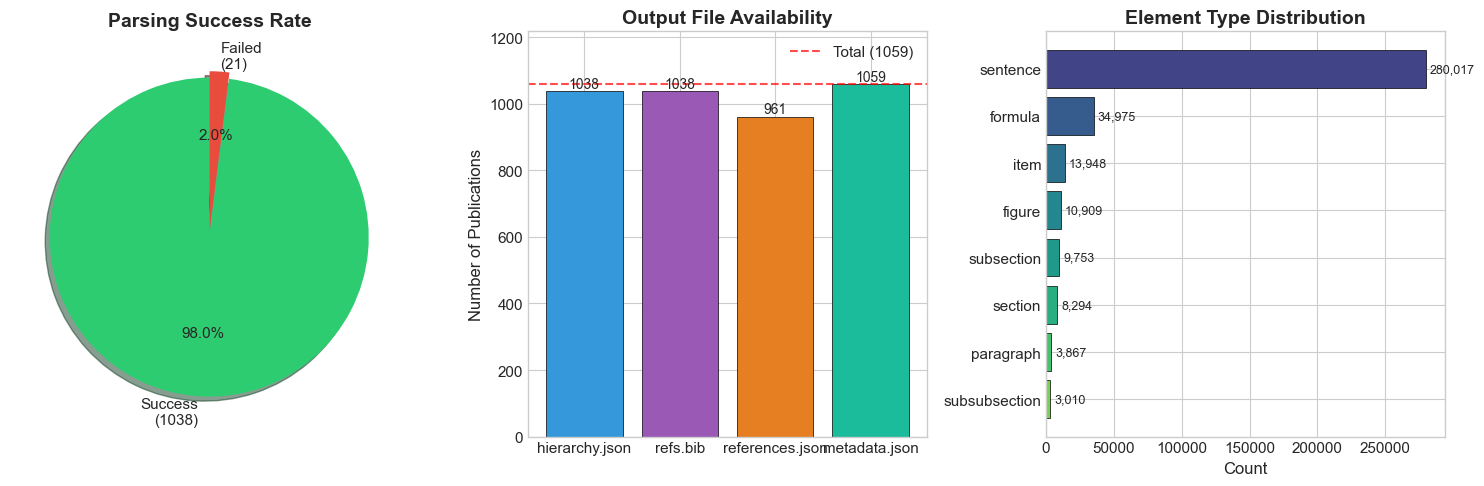


Saved: c:\Code\KHDL_Lab02_v2\output\parsing_statistics.png


In [39]:
# Visualization: Parsing Success Rate
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Parsing Success Pie Chart
ax1 = axes[0]
sizes = [parsing_stats['successful_parsing'], parsing_stats['failed_parsing']]
labels = [f'Success\n({sizes[0]})', f'Failed\n({sizes[1]})']
colors = ['#2ecc71', '#e74c3c']
explode = (0.02, 0.02)
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, explode=explode, shadow=True)
ax1.set_title('Parsing Success Rate', fontsize=14, fontweight='bold')

# 2. File Availability Bar Chart
ax2 = axes[1]
files = ['hierarchy.json', 'refs.bib', 'references.json', 'metadata.json']
counts = [
    parsing_stats['with_hierarchy'],
    parsing_stats['with_refs_bib'],
    parsing_stats['with_references_json'],
    parsing_stats['with_metadata']
]
colors = ['#3498db', '#9b59b6', '#e67e22', '#1abc9c']
bars = ax2.bar(files, counts, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Number of Publications', fontsize=12)
ax2.set_title('Output File Availability', fontsize=14, fontweight='bold')
ax2.axhline(y=total, color='red', linestyle='--', alpha=0.7, label=f'Total ({total})')
ax2.legend()
for bar, count in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             str(count), ha='center', va='bottom', fontsize=10)
ax2.set_ylim(0, max(counts) * 1.15)

# 3. Element Type Distribution
ax3 = axes[2]
elem_types = list(parsing_stats['element_counts'].keys())
elem_counts = list(parsing_stats['element_counts'].values())
if elem_types:
    # Sort by count and take top 8
    sorted_pairs = sorted(zip(elem_types, elem_counts), key=lambda x: -x[1])[:8]
    elem_types, elem_counts = zip(*sorted_pairs)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(elem_types)))
    bars = ax3.barh(elem_types, elem_counts, color=colors, edgecolor='black', linewidth=0.5)
    ax3.set_xlabel('Count', fontsize=12)
    ax3.set_title('Element Type Distribution', fontsize=14, fontweight='bold')
    ax3.invert_yaxis()
    for bar, count in zip(bars, elem_counts):
        ax3.text(bar.get_width() + max(elem_counts)*0.01, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'parsing_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'parsing_statistics.png'}")

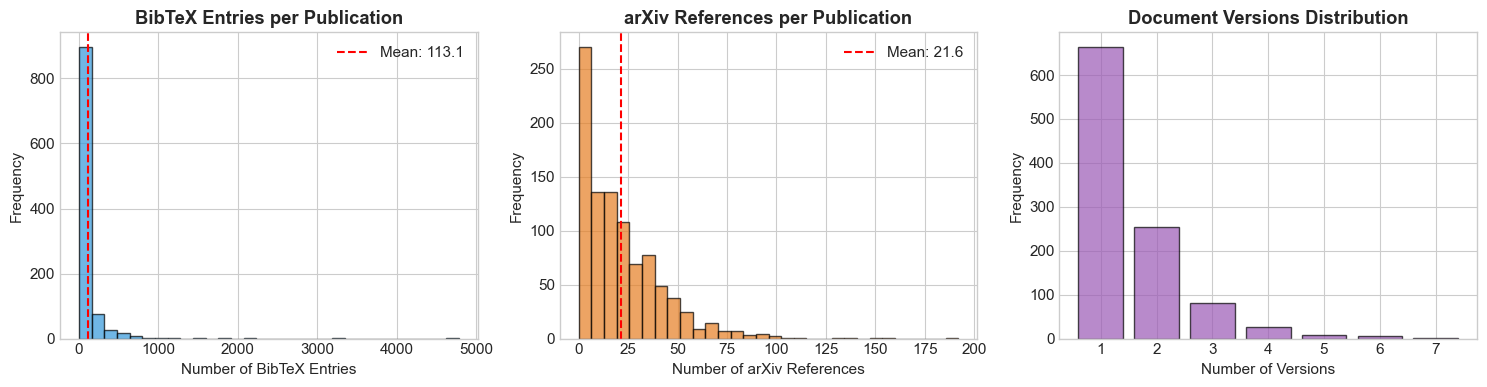


Saved: c:\Code\KHDL_Lab02_v2\output\distribution_statistics.png


In [40]:
# Visualization: Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. BibTeX entries distribution
ax1 = axes[0]
if parsing_stats['bibtex_entries']:
    ax1.hist(parsing_stats['bibtex_entries'], bins=30, color='#3498db', 
             edgecolor='black', alpha=0.7)
    ax1.axvline(np.mean(parsing_stats['bibtex_entries']), color='red', 
                linestyle='--', label=f'Mean: {np.mean(parsing_stats["bibtex_entries"]):.1f}')
    ax1.set_xlabel('Number of BibTeX Entries')
    ax1.set_ylabel('Frequency')
    ax1.set_title('BibTeX Entries per Publication', fontweight='bold')
    ax1.legend()

# 2. ArXiv references distribution
ax2 = axes[1]
if parsing_stats['reference_counts']:
    ax2.hist(parsing_stats['reference_counts'], bins=30, color='#e67e22', 
             edgecolor='black', alpha=0.7)
    ax2.axvline(np.mean(parsing_stats['reference_counts']), color='red', 
                linestyle='--', label=f'Mean: {np.mean(parsing_stats["reference_counts"]):.1f}')
    ax2.set_xlabel('Number of arXiv References')
    ax2.set_ylabel('Frequency')
    ax2.set_title('arXiv References per Publication', fontweight='bold')
    ax2.legend()

# 3. Version count distribution
ax3 = axes[2]
if parsing_stats['version_counts']:
    unique_versions = list(set(parsing_stats['version_counts']))
    version_freq = [parsing_stats['version_counts'].count(v) for v in unique_versions]
    ax3.bar(unique_versions, version_freq, color='#9b59b6', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Number of Versions')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Document Versions Distribution', fontweight='bold')
    ax3.set_xticks(unique_versions)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distribution_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'distribution_statistics.png'}")

## 3. Matching Statistics

Evaluation metrics for the reference matching model.

In [41]:
def collect_matching_statistics(data_dir: Path) -> Dict:
    """Collect statistics about reference matching."""
    stats = {
        'total_labeled': 0,
        'train_count': 0,
        'valid_count': 0,
        'test_count': 0,
        'total_labels': 0,
        'labels_per_pub': [],
        'predictions': [],  # (pred_list, ground_truth)
        'partition_labels': defaultdict(int),
    }
    
    for pub_path in sorted(data_dir.iterdir()):
        if not pub_path.is_dir():
            continue
        
        pred_file = pub_path / 'pred.json'
        if not pred_file.exists():
            continue
        
        try:
            with open(pred_file, 'r', encoding='utf-8') as f:
                pred_data = json.load(f)
            
            stats['total_labeled'] += 1
            partition = pred_data.get('partition', 'train')
            
            if partition == 'train':
                stats['train_count'] += 1
            elif partition == 'valid':
                stats['valid_count'] += 1
            elif partition == 'test':
                stats['test_count'] += 1
            
            groundtruth = pred_data.get('groundtruth', {})
            predictions = pred_data.get('prediction', {})
            
            num_labels = len(groundtruth)
            stats['total_labels'] += num_labels
            stats['labels_per_pub'].append(num_labels)
            stats['partition_labels'][partition] += num_labels
            
            # Collect predictions for MRR
            for bib_key, true_arxiv in groundtruth.items():
                pred_list = predictions.get(bib_key, [])
                stats['predictions'].append({
                    'partition': partition,
                    'pred_list': pred_list,
                    'ground_truth': true_arxiv
                })
        except:
            continue
    
    return stats

# Collect matching statistics
print("Collecting matching statistics...")
matching_stats = collect_matching_statistics(DATA_DIR)
print(f"Found {matching_stats['total_labeled']} labeled publications")

Found 656 labeled publications


In [42]:
# Display matching summary
print("=" * 60)
print("MATCHING STATISTICS SUMMARY")
print("=" * 60)

print(f"\n{'Dataset Split':<25} {'Pubs':>8} {'Labels':>10}")
print("-" * 45)
print(f"{'Train':<25} {matching_stats['train_count']:>8} {matching_stats['partition_labels']['train']:>10}")
print(f"{'Validation':<25} {matching_stats['valid_count']:>8} {matching_stats['partition_labels']['valid']:>10}")
print(f"{'Test':<25} {matching_stats['test_count']:>8} {matching_stats['partition_labels']['test']:>10}")
print("-" * 45)
print(f"{'Total':<25} {matching_stats['total_labeled']:>8} {matching_stats['total_labels']:>10}")

# Labels per publication
if matching_stats['labels_per_pub']:
    labels = np.array(matching_stats['labels_per_pub'])
    print(f"\n{'Labels per Publication':<25}")
    print("-" * 45)
    print(f"  Mean: {np.mean(labels):.1f}")
    print(f"  Median: {np.median(labels):.0f}")
    print(f"  Min/Max: {np.min(labels)} / {np.max(labels)}")

MATCHING STATISTICS SUMMARY

Dataset Split                 Pubs     Labels
---------------------------------------------
Train                          654       6166
Validation                       1          5
Test                             1          2
---------------------------------------------
Total                          656       6173

Labels per Publication   
---------------------------------------------
  Mean: 9.4
  Median: 5
  Min/Max: 1 / 91


In [43]:
# Calculate evaluation metrics
def evaluate_by_partition(predictions: List[Dict]) -> Dict:
    """Calculate MRR and Precision@K for each partition."""
    results = {}
    
    for partition in ['train', 'valid', 'test', 'all']:
        if partition == 'all':
            subset = predictions
        else:
            subset = [p for p in predictions if p['partition'] == partition]
        
        if not subset:
            continue
        
        # Filter to only predictions with non-empty pred_list
        with_preds = [p for p in subset if p['pred_list']]
        
        pred_lists = [p['pred_list'] for p in with_preds]
        ground_truths = [p['ground_truth'] for p in with_preds]
        
        if not pred_lists:
            results[partition] = {
                'count': len(subset),
                'with_predictions': 0,
                'mrr': 0.0,
                'p@1': 0.0,
                'p@3': 0.0,
                'p@5': 0.0
            }
            continue
        
        mrr = calculate_mrr(pred_lists, ground_truths)
        p1 = calculate_precision_at_k(pred_lists, ground_truths, k=1)
        p3 = calculate_precision_at_k(pred_lists, ground_truths, k=3)
        p5 = calculate_precision_at_k(pred_lists, ground_truths, k=5)
        
        results[partition] = {
            'count': len(subset),
            'with_predictions': len(with_preds),
            'mrr': mrr,
            'p@1': p1,
            'p@3': p3,
            'p@5': p5
        }
    
    return results

# Evaluate
if matching_stats['predictions']:
    eval_results = evaluate_by_partition(matching_stats['predictions'])
    
    print("\n" + "=" * 70)
    print("EVALUATION RESULTS (MRR and Precision@K)")
    print("=" * 70)
    print(f"\n{'Partition':<12} {'Count':>8} {'w/Pred':>8} {'MRR':>10} {'P@1':>10} {'P@3':>10} {'P@5':>10}")
    print("-" * 70)
    
    for partition in ['train', 'valid', 'test', 'all']:
        if partition in eval_results:
            r = eval_results[partition]
            print(f"{partition:<12} {r['count']:>8} {r['with_predictions']:>8} "
                  f"{r['mrr']:>10.4f} {r['p@1']:>10.4f} {r['p@3']:>10.4f} {r['p@5']:>10.4f}")
else:
    print("\nNo predictions found. Run the matching pipeline first.")
    eval_results = {}


EVALUATION RESULTS (MRR and Precision@K)

Partition       Count   w/Pred        MRR        P@1        P@3        P@5
----------------------------------------------------------------------
train            6166     6166     0.7446     0.6409     0.8422     0.9059
valid               5        5     0.9000     0.8000     1.0000     1.0000
test                2        2     1.0000     1.0000     1.0000     1.0000
all              6173     6173     0.7448     0.6412     0.8424     0.9060


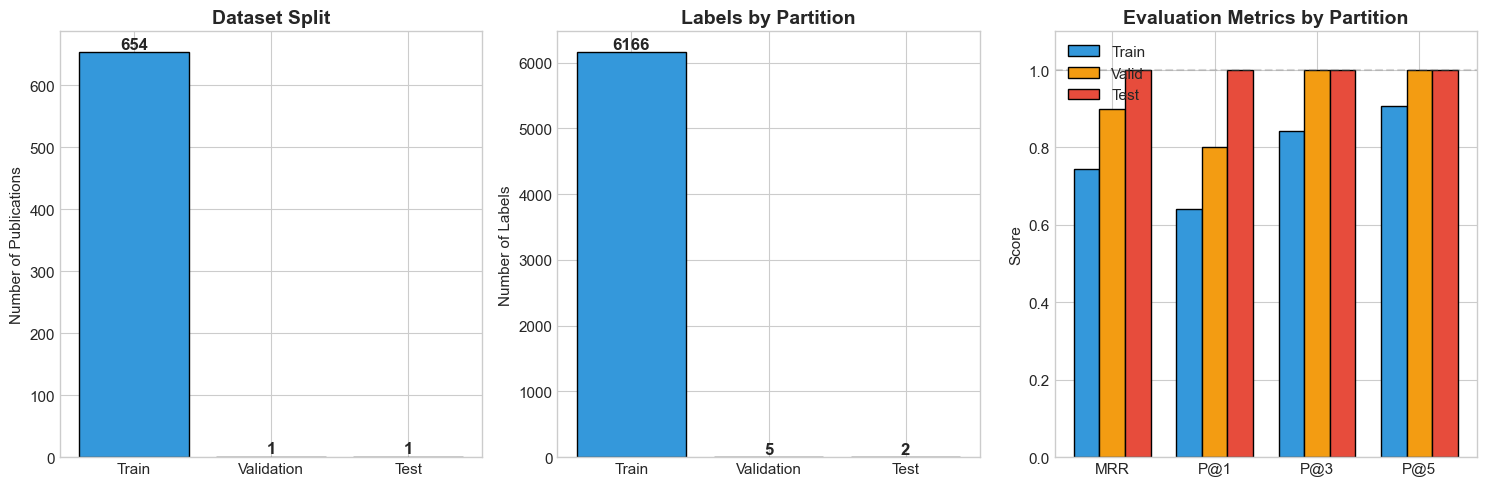


Saved: c:\Code\KHDL_Lab02_v2\output\matching_statistics.png


In [44]:
# Visualization: Matching Statistics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Dataset Split
ax1 = axes[0]
partitions = ['Train', 'Validation', 'Test']
counts = [matching_stats['train_count'], matching_stats['valid_count'], matching_stats['test_count']]
colors = ['#3498db', '#f39c12', '#e74c3c']
bars = ax1.bar(partitions, counts, color=colors, edgecolor='black')
ax1.set_ylabel('Number of Publications')
ax1.set_title('Dataset Split', fontweight='bold', fontsize=14)
for bar, count in zip(bars, counts):
    if count > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Labels by Partition
ax2 = axes[1]
label_counts = [matching_stats['partition_labels'].get(p, 0) for p in ['train', 'valid', 'test']]
bars = ax2.bar(partitions, label_counts, color=colors, edgecolor='black')
ax2.set_ylabel('Number of Labels')
ax2.set_title('Labels by Partition', fontweight='bold', fontsize=14)
for bar, count in zip(bars, label_counts):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. Evaluation Metrics
ax3 = axes[2]
if eval_results:
    metrics = ['MRR', 'P@1', 'P@3', 'P@5']
    x = np.arange(len(metrics))
    width = 0.25
    
    for i, (partition, color) in enumerate(zip(['train', 'valid', 'test'], colors)):
        if partition in eval_results:
            r = eval_results[partition]
            values = [r['mrr'], r['p@1'], r['p@3'], r['p@5']]
            ax3.bar(x + i*width, values, width, label=partition.capitalize(), color=color, edgecolor='black')
    
    ax3.set_ylabel('Score')
    ax3.set_title('Evaluation Metrics by Partition', fontweight='bold', fontsize=14)
    ax3.set_xticks(x + width)
    ax3.set_xticklabels(metrics)
    ax3.legend()
    ax3.set_ylim(0, 1.1)
    ax3.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No evaluation results\nRun matching pipeline first', 
             ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Evaluation Metrics', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'matching_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'matching_statistics.png'}")

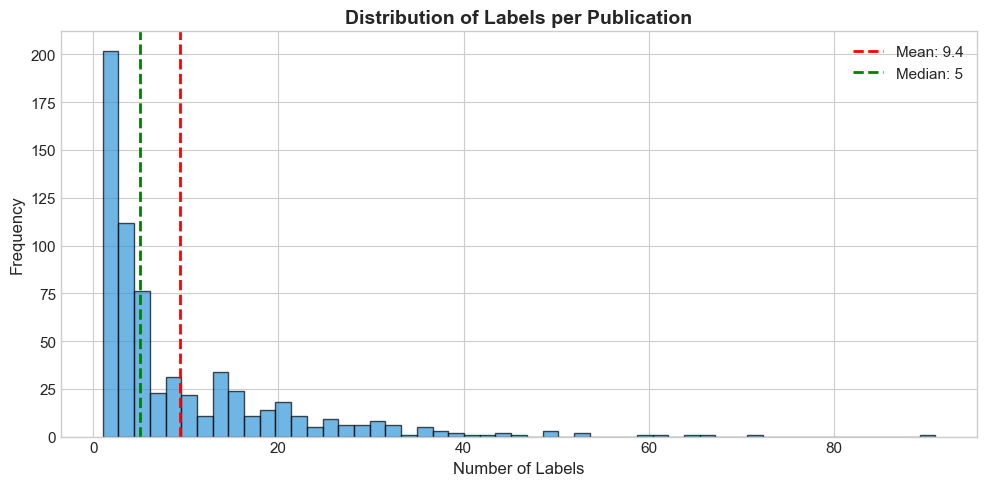


Saved: c:\Code\KHDL_Lab02_v2\output\labels_distribution.png


In [45]:
# Visualization: Labels per publication histogram
if matching_stats['labels_per_pub']:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    labels = matching_stats['labels_per_pub']
    ax.hist(labels, bins=max(10, len(set(labels))), color='#3498db', 
            edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(labels), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {np.mean(labels):.1f}')
    ax.axvline(np.median(labels), color='green', linestyle='--', linewidth=2,
               label=f'Median: {np.median(labels):.0f}')
    
    ax.set_xlabel('Number of Labels', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Labels per Publication', fontweight='bold', fontsize=14)
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'labels_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'labels_distribution.png'}")

## 4. Feature Importance Analysis

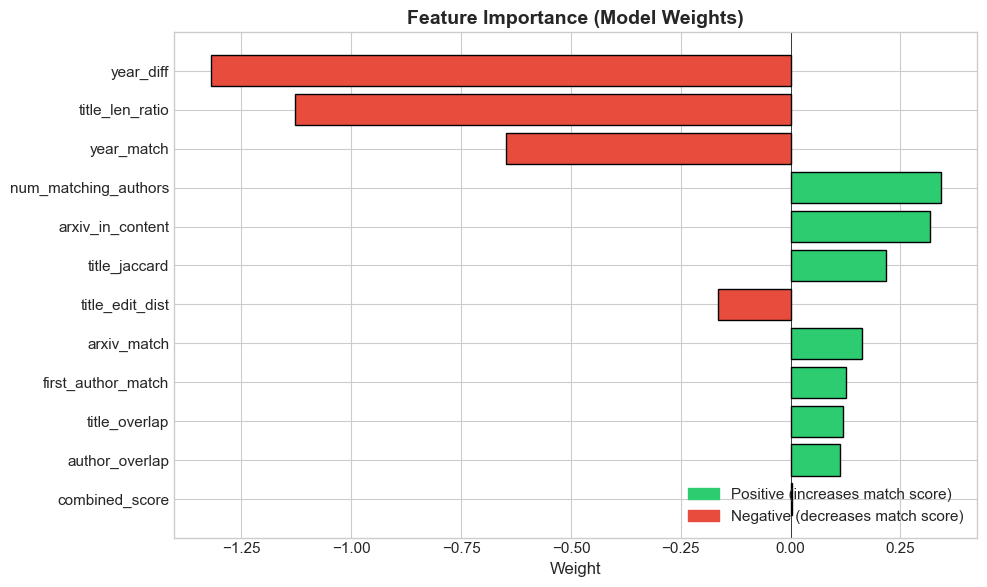


Saved: c:\Code\KHDL_Lab02_v2\output\feature_importance.png


In [46]:
# Feature importance visualization
if model.weights is not None:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    feature_names = model.FEATURE_NAMES
    weights = model.weights
    
    # Sort by absolute weight
    sorted_idx = np.argsort(np.abs(weights))[::-1]
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_weights = weights[sorted_idx]
    
    colors = ['#2ecc71' if w >= 0 else '#e74c3c' for w in sorted_weights]
    bars = ax.barh(sorted_names, sorted_weights, color=colors, edgecolor='black')
    
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('Weight', fontsize=12)
    ax.set_title('Feature Importance (Model Weights)', fontweight='bold', fontsize=14)
    ax.invert_yaxis()
    
    # Add legend
    positive_patch = mpatches.Patch(color='#2ecc71', label='Positive (increases match score)')
    negative_patch = mpatches.Patch(color='#e74c3c', label='Negative (decreases match score)')
    ax.legend(handles=[positive_patch, negative_patch], loc='lower right')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUTPUT_DIR / 'feature_importance.png'}")
else:
    print("No trained model available for feature importance analysis.")

## 5. Summary Report

In [47]:
# Generate summary report
summary = {
    'parsing': {
        'total_publications': parsing_stats['total_publications'],
        'successful': parsing_stats['successful_parsing'],
        'success_rate': parsing_stats['successful_parsing'] / parsing_stats['total_publications'] * 100 if parsing_stats['total_publications'] > 0 else 0,
        'with_refs_bib': parsing_stats['with_refs_bib'],
        'with_references_json': parsing_stats['with_references_json'],
        'total_elements': sum(parsing_stats['element_counts'].values()),
        'element_types': dict(parsing_stats['element_counts']),
    },
    'matching': {
        'labeled_publications': matching_stats['total_labeled'],
        'total_labels': matching_stats['total_labels'],
        'train_count': matching_stats['train_count'],
        'valid_count': matching_stats['valid_count'],
        'test_count': matching_stats['test_count'],
    },
    'evaluation': eval_results if eval_results else {}
}

# Save summary
summary_path = OUTPUT_DIR / 'pipeline_summary.json'
OUTPUT_DIR.mkdir(exist_ok=True)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print("=" * 70)
print("PIPELINE SUMMARY REPORT")
print("=" * 70)
print(f"\n{'PARSING':-^70}")
print(f"  Total Publications: {summary['parsing']['total_publications']}")
print(f"  Successfully Parsed: {summary['parsing']['successful']} ({summary['parsing']['success_rate']:.1f}%)")
print(f"  Total Hierarchy Elements: {summary['parsing']['total_elements']:,}")

print(f"\n{'MATCHING':-^70}")
print(f"  Labeled Publications: {summary['matching']['labeled_publications']}")
print(f"  Total Labels: {summary['matching']['total_labels']}")
print(f"  Train/Valid/Test: {summary['matching']['train_count']}/{summary['matching']['valid_count']}/{summary['matching']['test_count']}")

if eval_results and 'all' in eval_results:
    print(f"\n{'EVALUATION (Overall)':-^70}")
    r = eval_results['all']
    print(f"  MRR: {r['mrr']:.4f}")
    print(f"  Precision@1: {r['p@1']:.4f}")
    print(f"  Precision@3: {r['p@3']:.4f}")
    print(f"  Precision@5: {r['p@5']:.4f}")

print(f"\n{'='*70}")
print(f"Summary saved to: {summary_path}")

PIPELINE SUMMARY REPORT

-------------------------------PARSING--------------------------------
  Total Publications: 1059
  Successfully Parsed: 1038 (98.0%)
  Total Hierarchy Elements: 369,887

-------------------------------MATCHING-------------------------------
  Labeled Publications: 656
  Total Labels: 6173
  Train/Valid/Test: 654/1/1

-------------------------EVALUATION (Overall)-------------------------
  MRR: 0.7448
  Precision@1: 0.6412
  Precision@3: 0.8424
  Precision@5: 0.9060

Summary saved to: c:\Code\KHDL_Lab02_v2\output\pipeline_summary.json


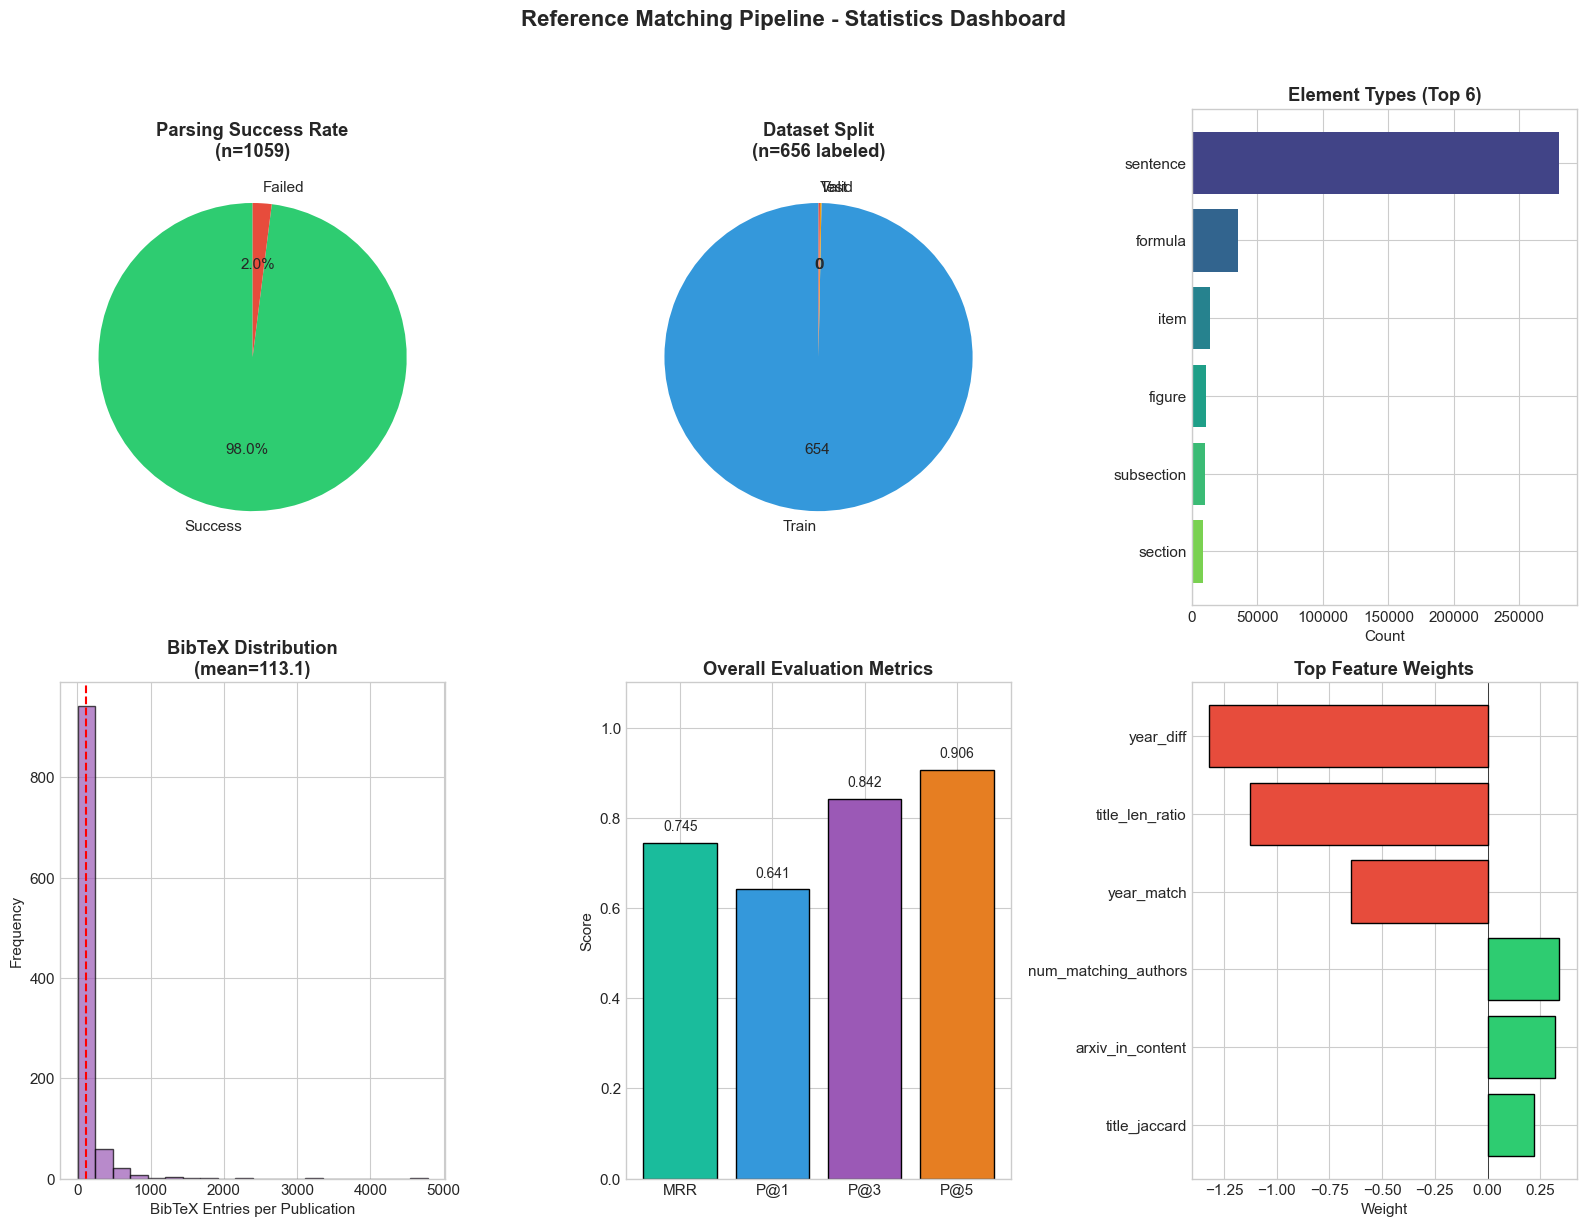


Dashboard saved to: c:\Code\KHDL_Lab02_v2\output\pipeline_dashboard.png


In [48]:
# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(16, 12))

# Title
fig.suptitle('Reference Matching Pipeline - Statistics Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Parsing Success (top left)
ax1 = fig.add_subplot(2, 3, 1)
sizes = [parsing_stats['successful_parsing'], parsing_stats['failed_parsing']]
colors = ['#2ecc71', '#e74c3c']
ax1.pie(sizes, labels=['Success', 'Failed'], colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title(f'Parsing Success Rate\n(n={sum(sizes)})', fontweight='bold')

# 2. Dataset Split (top center)
ax2 = fig.add_subplot(2, 3, 2)
partitions = ['Train', 'Valid', 'Test']
counts = [matching_stats['train_count'], matching_stats['valid_count'], matching_stats['test_count']]
colors = ['#3498db', '#f39c12', '#e74c3c']
ax2.pie([c if c > 0 else 0.001 for c in counts], labels=partitions, colors=colors, 
        autopct=lambda p: f'{int(p*sum(counts)/100)}' if p > 0 else '', startangle=90)
ax2.set_title(f'Dataset Split\n(n={sum(counts)} labeled)', fontweight='bold')

# 3. Element Types (top right)
ax3 = fig.add_subplot(2, 3, 3)
if parsing_stats['element_counts']:
    sorted_types = sorted(parsing_stats['element_counts'].items(), key=lambda x: -x[1])[:6]
    types, counts = zip(*sorted_types)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(types)))
    ax3.barh(types, counts, color=colors)
    ax3.set_xlabel('Count')
    ax3.set_title('Element Types (Top 6)', fontweight='bold')
    ax3.invert_yaxis()

# 4. BibTeX Distribution (bottom left)
ax4 = fig.add_subplot(2, 3, 4)
if parsing_stats['bibtex_entries']:
    ax4.hist(parsing_stats['bibtex_entries'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
    ax4.axvline(np.mean(parsing_stats['bibtex_entries']), color='red', linestyle='--')
    ax4.set_xlabel('BibTeX Entries per Publication')
    ax4.set_ylabel('Frequency')
    ax4.set_title(f'BibTeX Distribution\n(mean={np.mean(parsing_stats["bibtex_entries"]):.1f})', fontweight='bold')

# 5. Evaluation Metrics (bottom center)
ax5 = fig.add_subplot(2, 3, 5)
if eval_results and 'all' in eval_results:
    r = eval_results['all']
    metrics = ['MRR', 'P@1', 'P@3', 'P@5']
    values = [r['mrr'], r['p@1'], r['p@3'], r['p@5']]
    colors = ['#1abc9c', '#3498db', '#9b59b6', '#e67e22']
    bars = ax5.bar(metrics, values, color=colors, edgecolor='black')
    ax5.set_ylabel('Score')
    ax5.set_ylim(0, 1.1)
    ax5.set_title('Overall Evaluation Metrics', fontweight='bold')
    for bar, val in zip(bars, values):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
else:
    ax5.text(0.5, 0.5, 'No evaluation data', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Evaluation Metrics', fontweight='bold')

# 6. Feature Importance (bottom right)
ax6 = fig.add_subplot(2, 3, 6)
if model.weights is not None:
    sorted_idx = np.argsort(np.abs(model.weights))[::-1][:6]
    top_features = [model.FEATURE_NAMES[i] for i in sorted_idx]
    top_weights = model.weights[sorted_idx]
    colors = ['#2ecc71' if w >= 0 else '#e74c3c' for w in top_weights]
    ax6.barh(top_features, top_weights, color=colors, edgecolor='black')
    ax6.axvline(x=0, color='black', linewidth=0.5)
    ax6.set_xlabel('Weight')
    ax6.set_title('Top Feature Weights', fontweight='bold')
    ax6.invert_yaxis()
else:
    ax6.text(0.5, 0.5, 'No trained model', ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('Feature Importance', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pipeline_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDashboard saved to: {OUTPUT_DIR / 'pipeline_dashboard.png'}")